# UAS | Analisis Perbandingan Decision Tree dan Random Forest

Evaluasi Performa Akademik Mahasiswa (Higher Education Students Performance Evaluation) Menggunakan Algoritma Decision Tree dan Random Forest pada KNIME Analytics Platform

Analisis ini bertujuan untuk membandingkan performa algoritma Decision Tree dan Random Forest dalam mengklasifikasikan performa akademik mahasiswa berdasarkan karakteristik personal dan sosial ekonomi. Seluruh proses dilakukan menggunakan KNIME Analytics Platform dengan pendekatan visual workflow sehingga memudahkan proses eksplorasi data, pembangunan model, dan evaluasi hasil klasifikasi.

## Informasi Dataset Asli (Raw Data)

Berdasarkan dokumentasi resmi dari UCI Machine Learning Repository, dataset yang digunakan memiliki karakteristik sebagai berikut:

### Asal Data

Dataset dikumpulkan pada tahun 2019 dari mahasiswa Faculty of Engineering dan Faculty of Educational Sciences.

### Tujuan Utama

Dataset dibuat untuk memprediksi performa akademik mahasiswa pada akhir semester (end-of-term performances) menggunakan berbagai teknik Machine Learning.

### Karakteristik Atribut

Dataset terdiri dari 31 atribut utama yang mencakup:

- Pertanyaan 1–10 : Informasi personal mahasiswa (personal questions)
- Pertanyaan 11–16 : Informasi latar belakang keluarga (family questions)
- Pertanyaan 17–30 : Kebiasaan belajar dan pola pendidikan (education habits)
Missing Values

Dataset tidak memiliki nilai kosong (missing values).

### Lisensi

Dataset menggunakan lisensi Creative Commons Attribution 4.0 International (CC BY 4.0) yang memungkinkan penggunaan dan distribusi data dengan tetap mencantumkan sumber asli.

## Ringkasan Dataset dan Pra-pemrosesan Data

Sebelum memasuki tahap klasifikasi, dilakukan beberapa proses pra-pemrosesan untuk menyederhanakan data dan meningkatkan efektivitas model.

### Jumlah Data

Dataset terdiri dari:

- 145 baris data mahasiswa
- 33 kolom data

yang meliputi:

- Student ID
- Course ID
- 30 atribut pertanyaan
- 1 atribut target (GRADE)

## Pemilihan 8 Fitur Utama (Feature Selection)

Dari 30 atribut pertanyaan yang tersedia, analisis ini difokuskan hanya pada 8 fitur pertama, yaitu:

| No | Atribut          |
| -- | ---------------- |
| 1  | Student Age      |
| 2  | Gender           |
| 3  | High School Type |
| 4  | Scholarship Type |
| 5  | Additional Work  |
| 6  | Activity         |
| 7  | Partner Status   |
| 8  | Total Salary     |

Pemilihan 8 fitur dilakukan untuk:

Mengurangi kompleksitas model
Mempermudah interpretasi hasil
Mengurangi risiko overfitting
Membuat struktur pohon keputusan lebih mudah dianalisis

Pada KNIME, proses ini dilakukan menggunakan node Column Filter.

## Kategorisasi Label Target

Target asli dataset berupa nilai GRADE dengan rentang:

0 – 7

Karena jumlah data relatif sedikit (145 data), penggunaan 8 kelas secara langsung dapat menyebabkan distribusi data yang tidak seimbang dan menurunkan performa model.

Oleh karena itu dilakukan pengelompokan menjadi tiga kategori performa akademik:

| GRADE | Kategori |
| ----- | -------- |
| 0 – 2 | Rendah   |
| 3 – 5 | Sedang   |
| 6 – 7 | Tinggi   |

Interpretasi kategori:

- Rendah

Mewakili mahasiswa yang mengalami kesulitan akademik dan membutuhkan perhatian lebih.

- Sedang

Mewakili mahasiswa dengan performa akademik rata-rata yang telah memenuhi standar pembelajaran.

- Tinggi

Mewakili mahasiswa berprestasi yang memiliki penguasaan materi yang baik.

Transformasi ini dilakukan menggunakan node Rule Engine pada KNIME.



## Langkah-Langkah Aliran Kerja di KNIME Analytics Platform

1. CSV Reader Node

Tambahkan node CSV Reader ke workflow KNIME kemudian pilih file dataset DATA (1).csv.

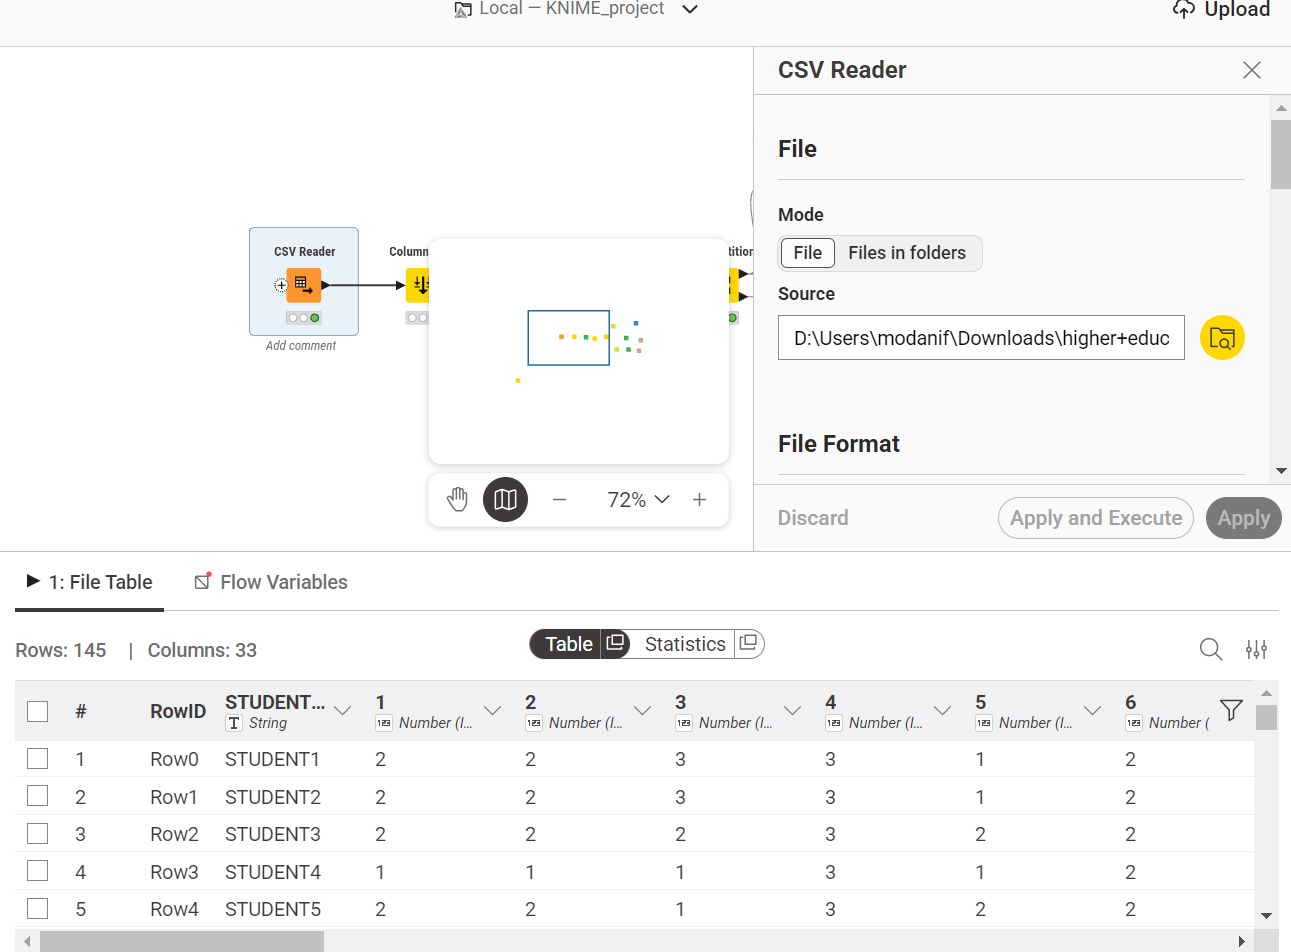

Node ini digunakan untuk membaca seluruh data yang akan digunakan dalam proses analisis.

2. Column Filter Node

Hubungkan CSV Reader ke node Column Filter.

Kolom yang dipertahankan:

1

2

3

4

5

6

7

8

GRADE

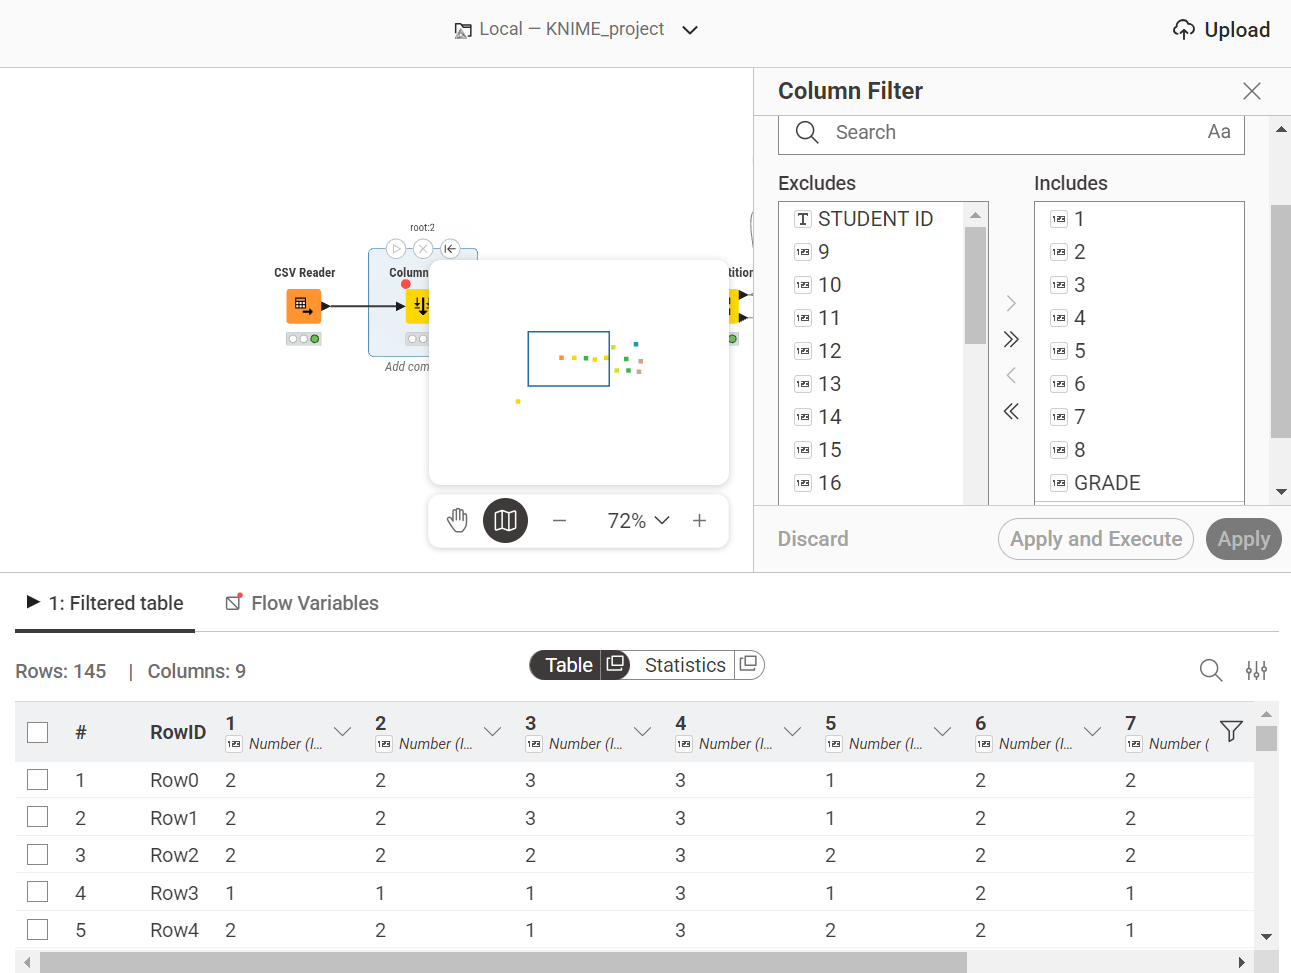

Kolom lain seperti:

9 – 30

COURSE ID

dipindahkan ke bagian Exclude.

3. Rule Engine Node

Hubungkan node Column Filter ke node Rule Engine.

Aturan yang digunakan:

$GRADE$ <= 2 => "Rendah"
$GRADE$ >= 3 AND $GRADE$ <= 5 => "Sedang"
TRUE => "Tinggi"

Pilih:

Append New Column

dengan nama:

Kategori_Grade

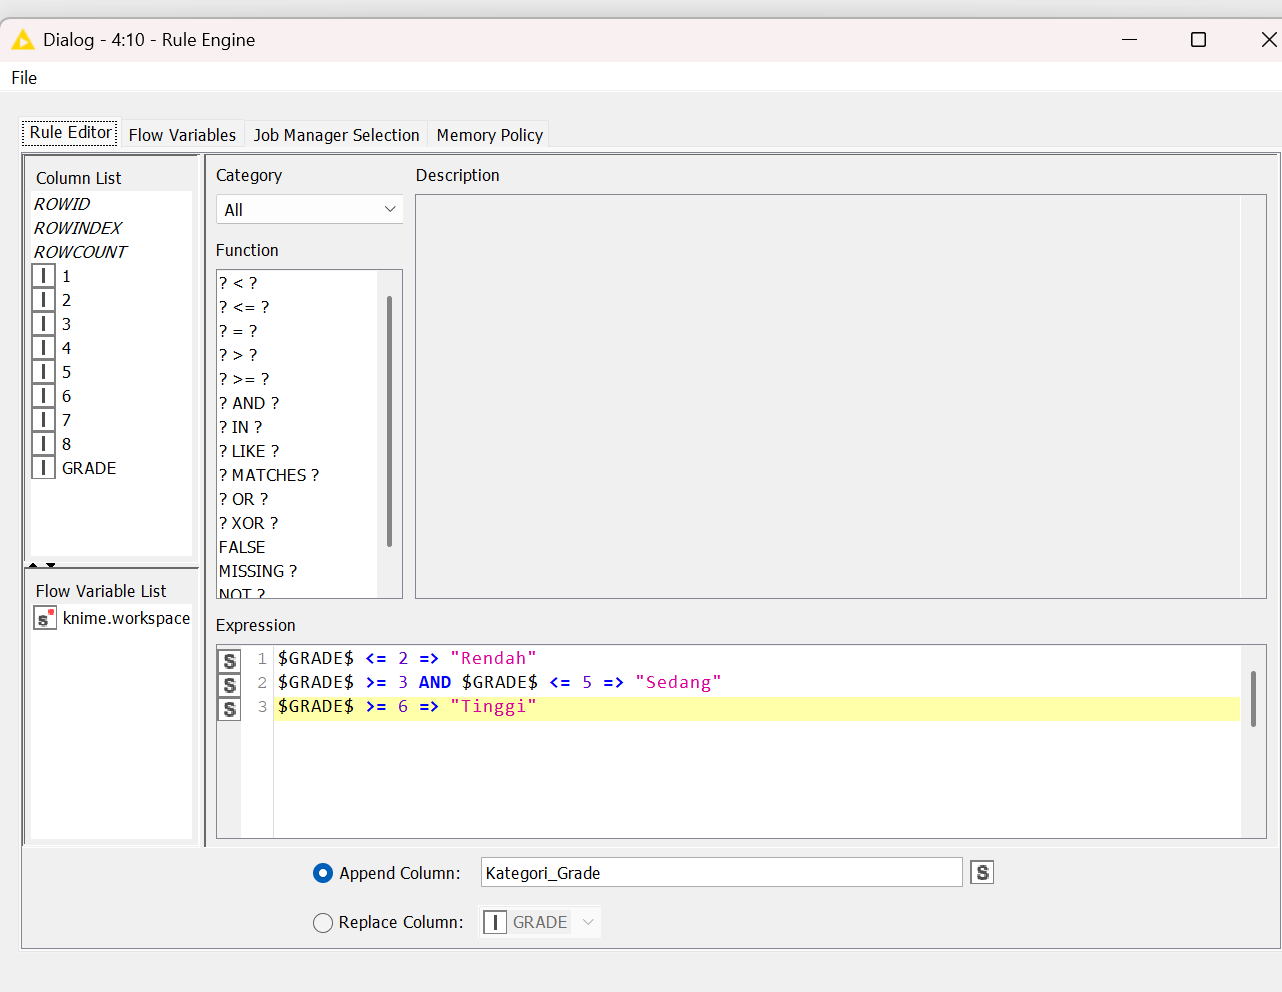


4. Column Filter Node (Kedua)

Tambahkan kembali node Column Filter.

Kolom yang dipertahankan:

1

2

3

4

5

6

7

8

Kategori_Grade

Kolom:

GRADE

dihapus dari proses analisis.

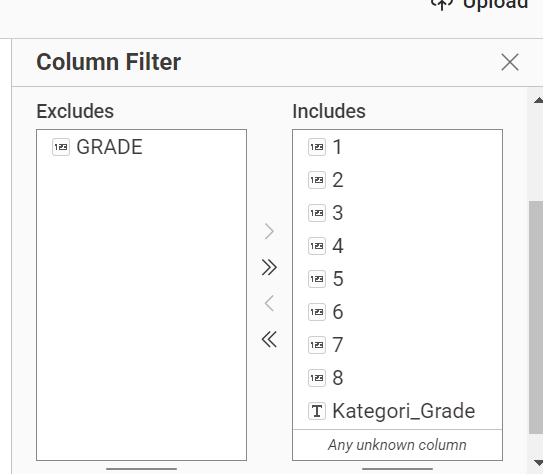

5. Table Partitioner Node

Hubungkan ke node Table Partitioner.

Konfigurasi:

| Parameter       | Nilai               |
| --------------- | ------------------- |
| Training Data   | 80%                 |
| Testing Data    | 20%                 |
| Sampling Method | Stratified Sampling |
| Group Column    | Kategori_Grade      |

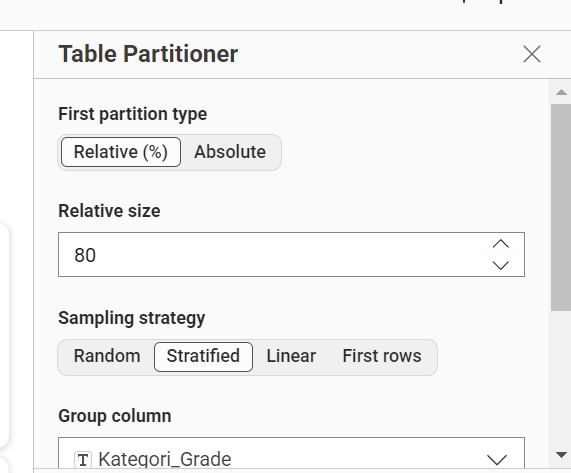

Node ini membagi dataset menjadi data latih dan data uji dengan distribusi kelas yang seimban

###  Implementasi Algoritma Decision Tree

6. Decision Tree Learner Node

Hubungkan output data training dari Table Partitioner ke node Decision Tree Learner.

Konfigurasi:

| Parameter                | Nilai                 |
| ------------------------ | --------------------- |
| Class Column             | Kategori_Grade        |
| Quality Measure          | Gain Ratio            |
| Pruning Method           | Reduced Error Pruning |
| Minimum Records per Node | 2                     |

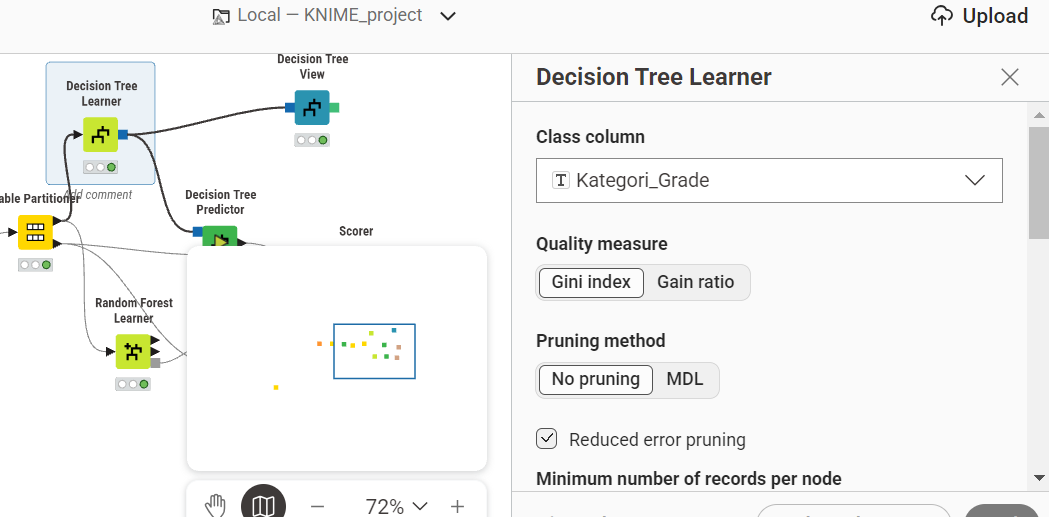

Node ini digunakan untuk membangun model Decision Tree berdasarkan data training.



7. Decision Tree Predictor Node

Hubungkan model dari Decision Tree Learner dan data testing dari Table Partitioner ke node Decision Tree Predictor.

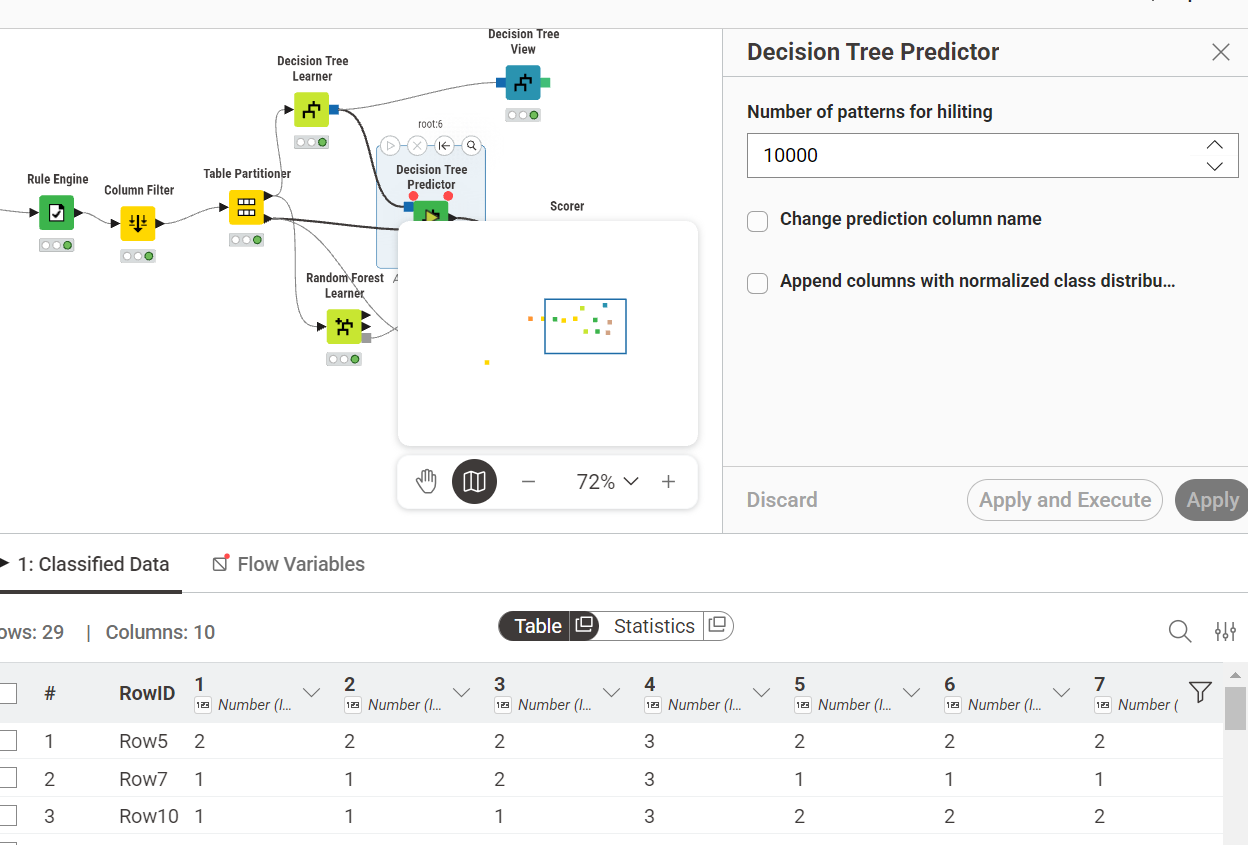

Node ini menghasilkan prediksi kategori performa akademik pada data testing.

8. Scorer Node

Hubungkan output predictor ke node Scorer.

Konfigurasi:

| Parameter     | Nilai                       |
| ------------- | --------------------------- |
| First Column  | Kategori_Grade              |
| Second Column | Prediction (Kategori_Grade) |

Hasil Decision Tree

Berdasarkan hasil pengujian diperoleh:

| Metrik       | Nilai |
| ------------ | ----- |
| Accuracy     | 0.31  |
| Accuracy (%) | 31.0% |

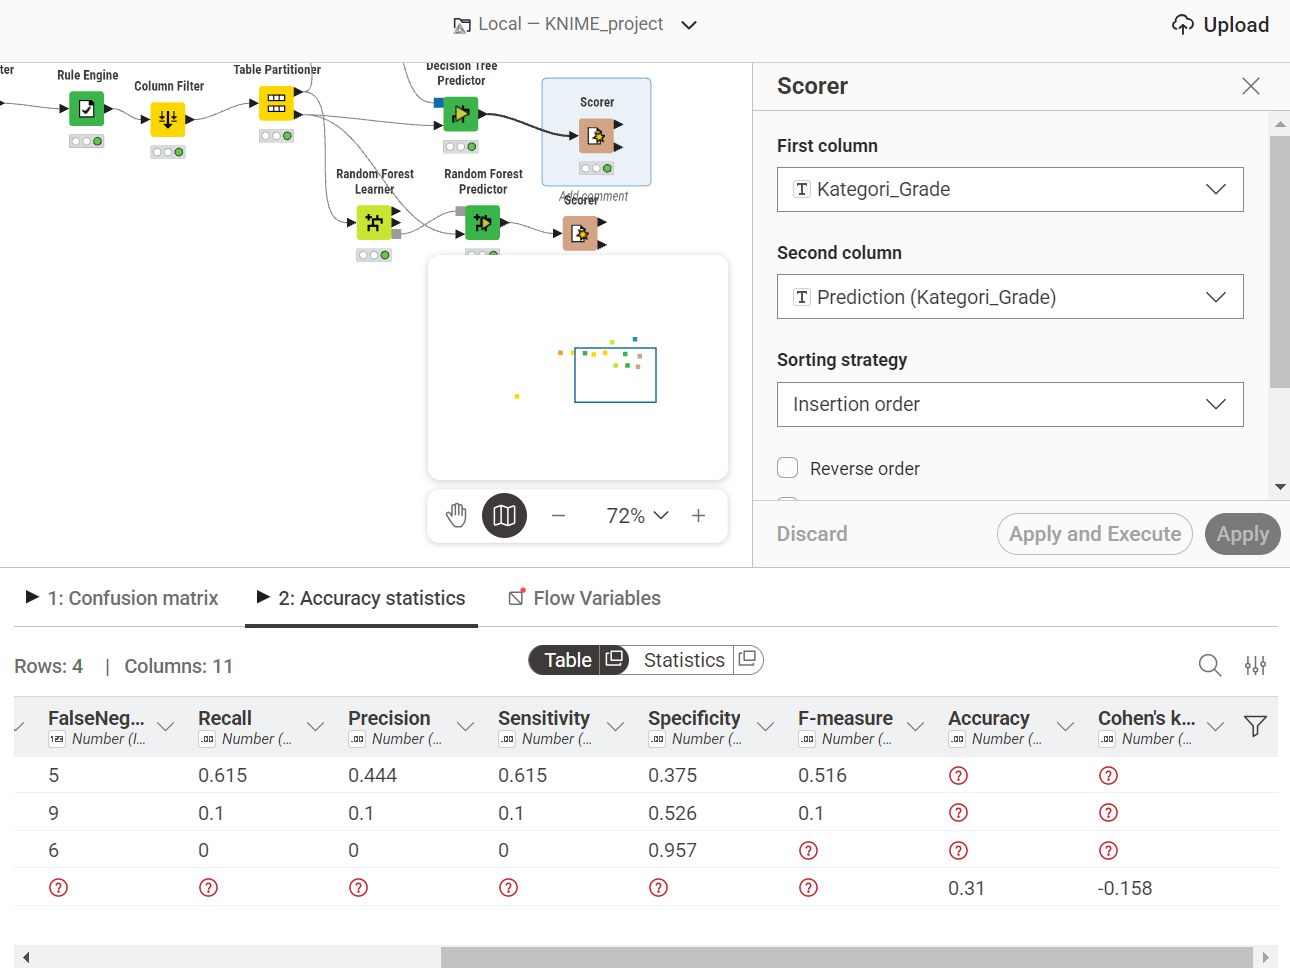

### Implementasi Algoritma Random Forest

9. Random Forest Learner Node

Buat workflow yang sama hingga Table Partitioner kemudian hubungkan data training ke node Random Forest Learner.

Konfigurasi:

| Parameter        | Nilai                  |
| ---------------- | ---------------------- |
| Target Column    | Kategori_Grade         |
| Split Criterion  | Information Gain Ratio |
| Number of Models | 100                    |

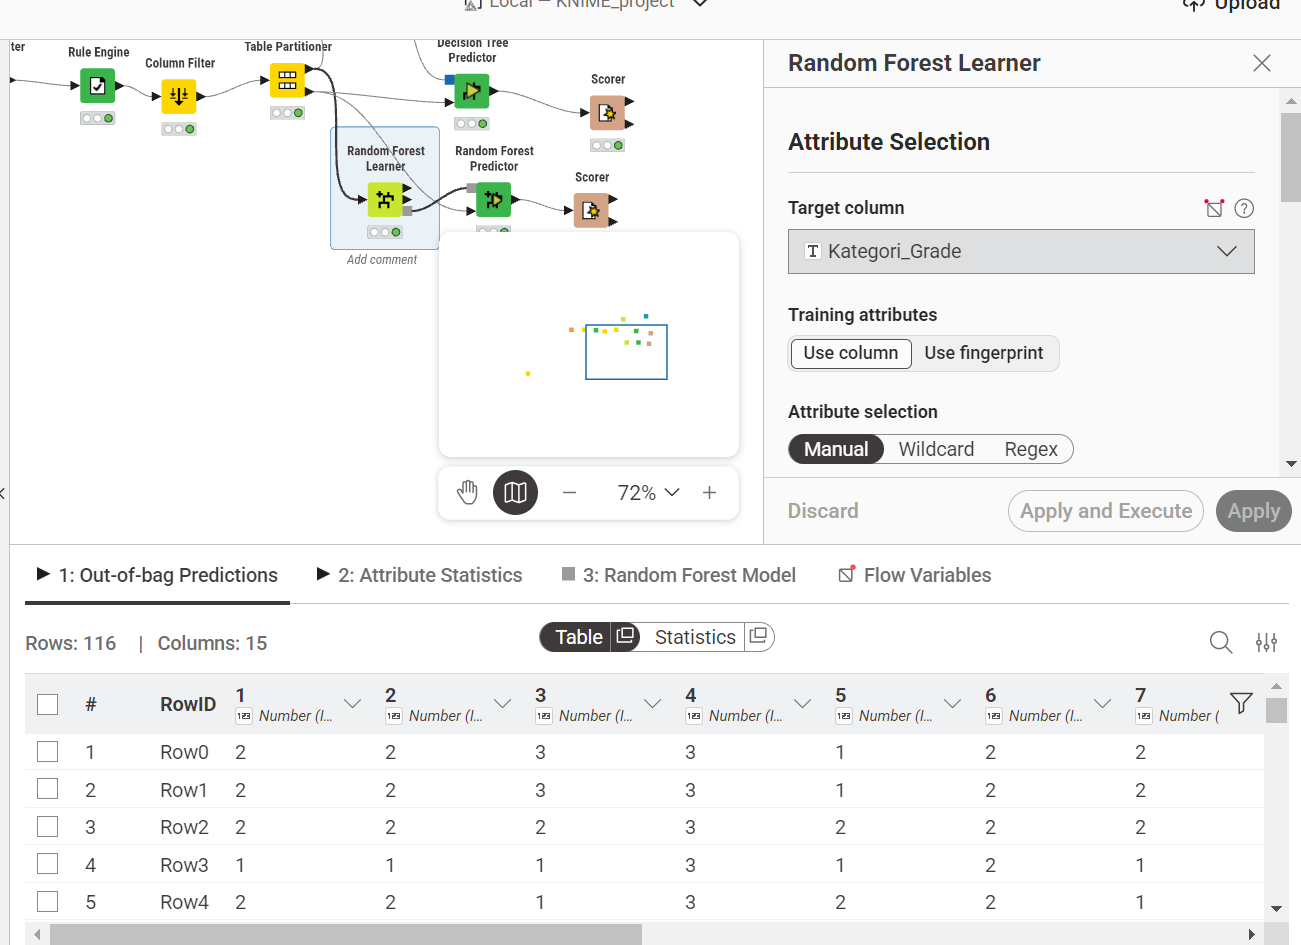

Node ini membangun 100 pohon keputusan yang kemudian digabungkan menjadi satu model ensemble.

10. Random Forest Predictor Node

Hubungkan model dari Random Forest Learner dan data testing dari Table Partitioner ke node Random Forest Predictor.

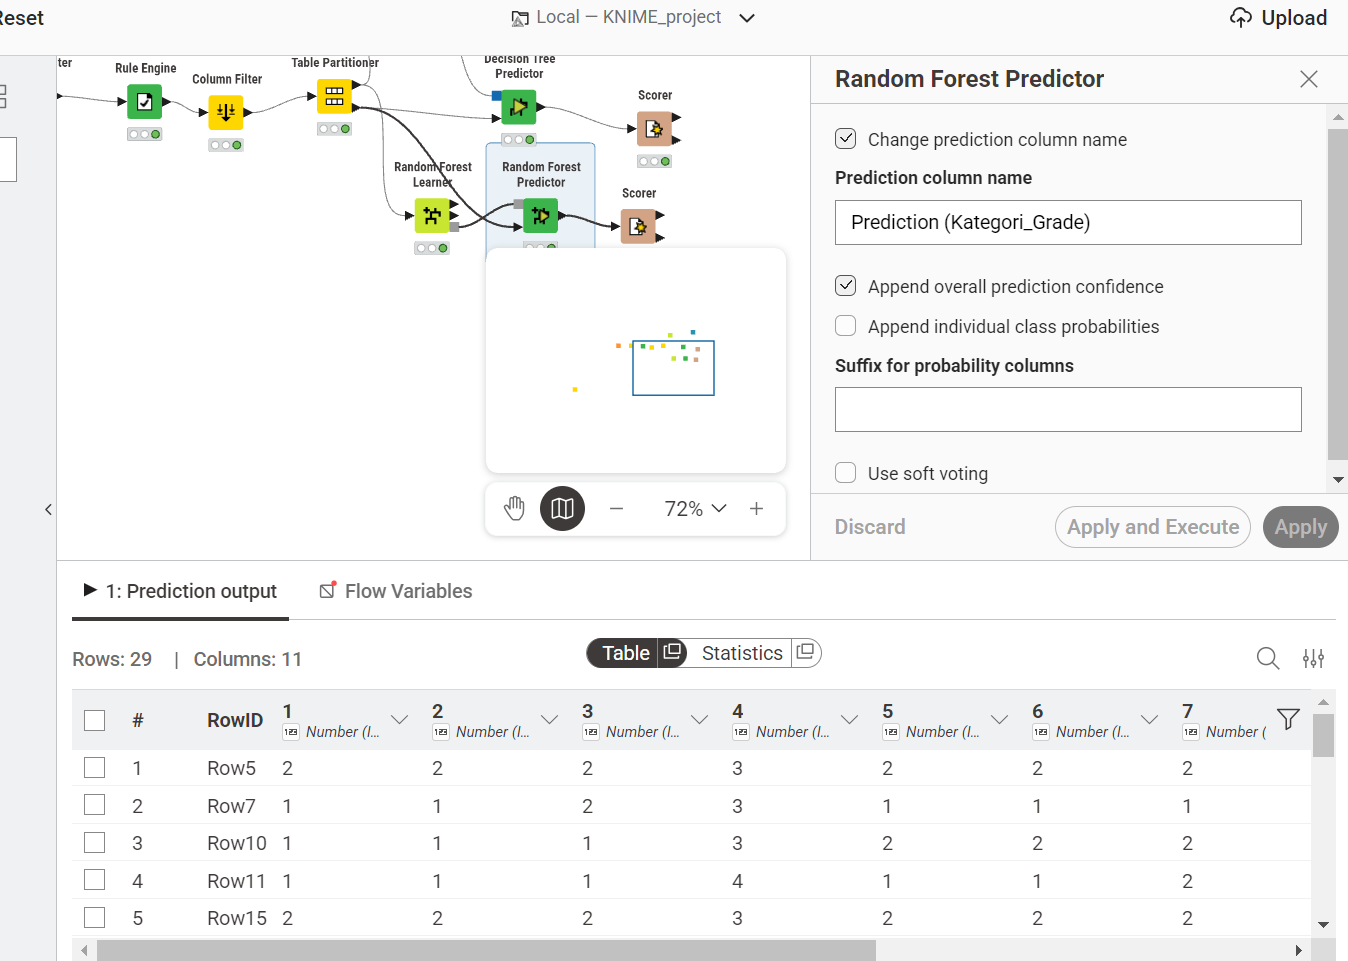

Node ini digunakan untuk memprediksi kategori performa akademik pada data testing.

11. Scorer Node

Hubungkan output predictor ke node Scorer.

Konfigurasi:

| Parameter     | Nilai                       |
| ------------- | --------------------------- |
| First Column  | Kategori_Grade              |
| Second Column | Prediction (Kategori_Grade) |

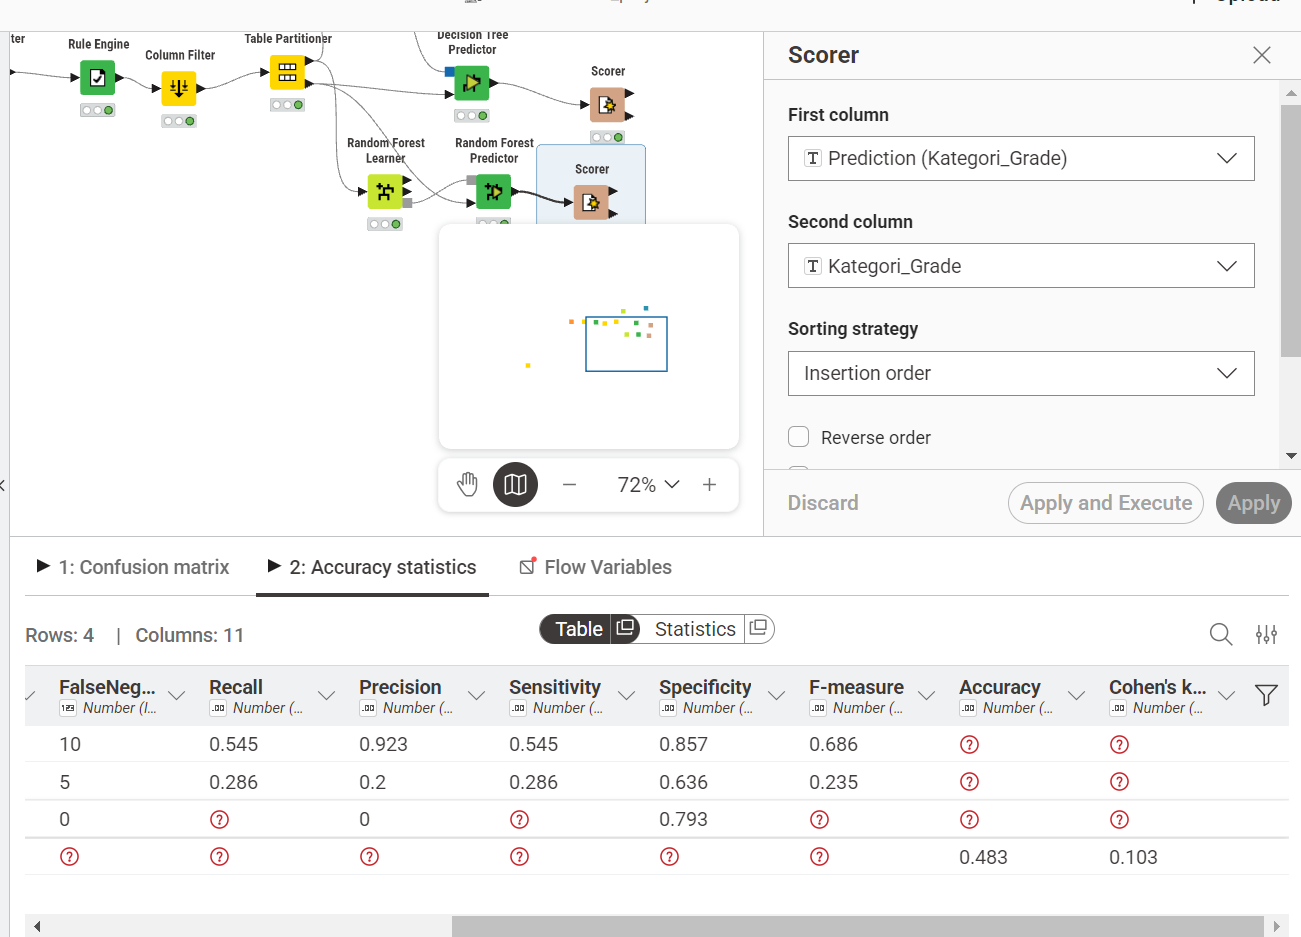

Hasil Random Forest

Berdasarkan hasil pengujian diperoleh:

| Metrik       | Nilai |
| ------------ | ----- |
| Accuracy     | 0.483 |
| Accuracy (%) | 48.3% |



### Hasil Evaluasi dan Perbandingan Performa Model
1. Perbandingan Akurasi Global
| Model         | Accuracy |
| ------------- | -------- |
| Decision Tree | 31.0%    |
| Random Forest | 48.3%    |

2. Analisis Performa Model

Hasil pengujian menunjukkan bahwa algoritma Random Forest memberikan performa yang lebih baik dibandingkan Decision Tree.

Peningkatan akurasi yang diperoleh adalah:

48.3%−31.0%

sehingga terjadi peningkatan sebesar 17,3%.

Random Forest mampu menghasilkan performa yang lebih baik karena menggunakan metode ensemble learning, yaitu menggabungkan banyak pohon keputusan yang dibangun secara acak. Pendekatan ini mampu mengurangi overfitting dan meningkatkan kemampuan generalisasi model terhadap data yang belum pernah dilihat sebelumnya.

Sebaliknya, Decision Tree hanya membangun satu pohon keputusan sehingga lebih rentan terhadap variasi data dan kesalahan klasifikasi.

### Kesimpulan

Berdasarkan hasil implementasi menggunakan KNIME Analytics Platform, diperoleh kesimpulan sebagai berikut:

Algoritma Decision Tree menghasilkan akurasi sebesar 31,0%.
Algoritma Random Forest menghasilkan akurasi sebesar 48,3%.
Random Forest memberikan peningkatan akurasi sebesar 17,3% dibandingkan Decision Tree.
Metode ensemble learning pada Random Forest mampu meningkatkan kualitas prediksi dan mengurangi risiko overfitting.
Berdasarkan hasil pengujian, Random Forest merupakan model yang lebih direkomendasikan untuk klasifikasi performa akademik mahasiswa pada dataset Higher Education Students Performance Evaluation karena menghasilkan tingkat akurasi yang lebih tinggi dibandingkan Decision Tree.